# PROYECTO FINAL APRENDIZAJE AUTOMÁTICO.

CLASIFICADOR DE SPAM


Para empezar este proyecto primero necesitamos cargar el dataset y las librerías correspondientes para el análisis del mismo.
Link del csv: https://archive.ics.uci.edu/dataset/94/spambase

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
df = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = df.data.features 
y = df.data.targets 

# unir en un solo DataFrame
data = pd.concat([X, y], axis=1)

# metadata 
print(df.metadata) 
  
# variable information 
print(df.variables) 

# ✅ GUARDAR correctamente
data.to_csv("dataset.csv", index=False)

# ✅ LEER como CSV
df1 = pd.read_csv("dataset.csv")

df1.head()

{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


El siguiente paso a seguir es comprobar que no haya datos faltantes en el dataset para evitar sesgos y errores

In [2]:
pd.isnull(df1).sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

Una vez comprobado que no hay errores pasaremos a estudiar los estadísticos básicos de cada variable y sus respectivas correspondencias entre variables.


In [3]:
# Vemos el tipo de cada variable por si hace falta cambiar algún tipo.
df1.info()
#Vemos que todos estan correctos pues pasamos a los estadísticos básicos.
df1.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


Vamos ahora a trabajar con las correlaciones para ver las relaciones entre ellas y ver si son spam o no spam. De esta manera y aplicando un umbral podremos anadir más o menos variables. Las mas cercanas a 0 las eliminaremos, pero no definitivamente, para un primer filtro exploratorio y reducir el análisis visual.


In [4]:
corr_target = df1.corr(numeric_only=True)['Class'].sort_values(ascending=False)

print(corr_target)

Class                         1.000000
word_freq_your                0.383234
word_freq_000                 0.334787
word_freq_remove              0.332117
char_freq_$                   0.323629
word_freq_you                 0.273651
word_freq_free                0.263215
word_freq_business            0.263204
capital_run_length_total      0.249164
word_freq_our                 0.241920
char_freq_!                   0.241888
word_freq_receive             0.234529
word_freq_over                0.232604
word_freq_order               0.231551
word_freq_money               0.216111
capital_run_length_longest    0.216097
word_freq_internet            0.206808
word_freq_email               0.204208
word_freq_all                 0.196988
word_freq_addresses           0.195902
word_freq_credit              0.189761
word_freq_mail                0.138962
word_freq_people              0.132927
word_freq_make                0.126208
capital_run_length_average    0.109999
word_freq_font           

Se observa que variables como word_freq_your y word_freq_000 presentan una correlación moderada con la variable objetivo, lo que indica que poseen un mayor poder predictivo en la detección de spam.

Por otro lado, variables como word_freq_will muestran una correlación cercana a cero, lo que sugiere que su contribución al modelo será limitada.

Class                         1.000000
word_freq_your                0.383234
word_freq_000                 0.334787
word_freq_remove              0.332117
char_freq_$                   0.323629
word_freq_you                 0.273651
word_freq_free                0.263215
word_freq_business            0.263204
capital_run_length_total      0.249164
word_freq_our                 0.241920
char_freq_!                   0.241888
word_freq_receive             0.234529
word_freq_over                0.232604
word_freq_order               0.231551
word_freq_money               0.216111
capital_run_length_longest    0.216097
word_freq_internet            0.206808
word_freq_email               0.204208
word_freq_all                 0.196988
word_freq_addresses           0.195902
word_freq_credit              0.189761
word_freq_650                -0.158800
word_freq_labs               -0.171095
word_freq_1999               -0.178045
word_freq_george             -0.183404
word_freq_hpl            

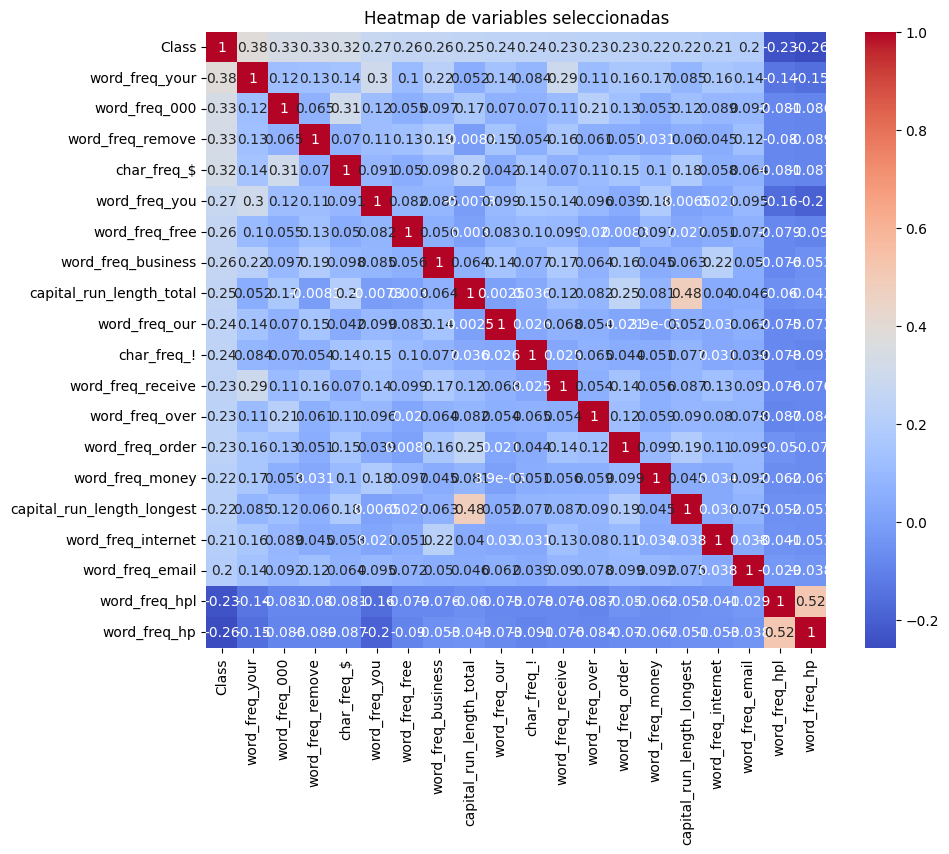

In [5]:
#Ahora aplicamos el umbral
important_features = corr_target[abs(corr_target) > 0.15]
print(important_features)
#volveremos a aplicar otro umbral para poder dibujar un heatmap claro de correlación donde se puedan diferenciar correctamente.
important_features2 = corr_target[abs(corr_target)> 0.20]
selected_features = important_features2.index
df_selected = df1[selected_features]
corr_matrix = df_selected.corr()
# Para modelado (SIN Class)
selected_features_model = [col for col in selected_features if col != 'Class']

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Heatmap de variables seleccionadas")
plt.show()

Detección de outliers

In [6]:
df_num = df1[selected_features]
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_num < (Q1 - 1.5 * IQR)) | 
            (df_num > (Q3 + 1.5 * IQR)))

print(outliers.sum())


Class                            0
word_freq_your                 229
word_freq_000                  679
word_freq_remove               807
char_freq_$                    811
word_freq_you                   75
word_freq_free                 957
word_freq_business             963
capital_run_length_total       550
word_freq_our                  501
char_freq_!                    411
word_freq_receive              709
word_freq_over                 999
word_freq_order                773
word_freq_money                735
capital_run_length_longest     463
word_freq_internet             824
word_freq_email               1038
word_freq_hpl                  811
word_freq_hp                  1090
dtype: int64


Se detectó un número elevado de valores atípicos en las variables. Sin embargo, dado que estas variables representan frecuencias de palabras, dichos valores no se consideran errores sino parte inherente de los datos.

Por ello, no se eliminaron y se aplicaran transformaciones logarítmicas para reducir su impacto.

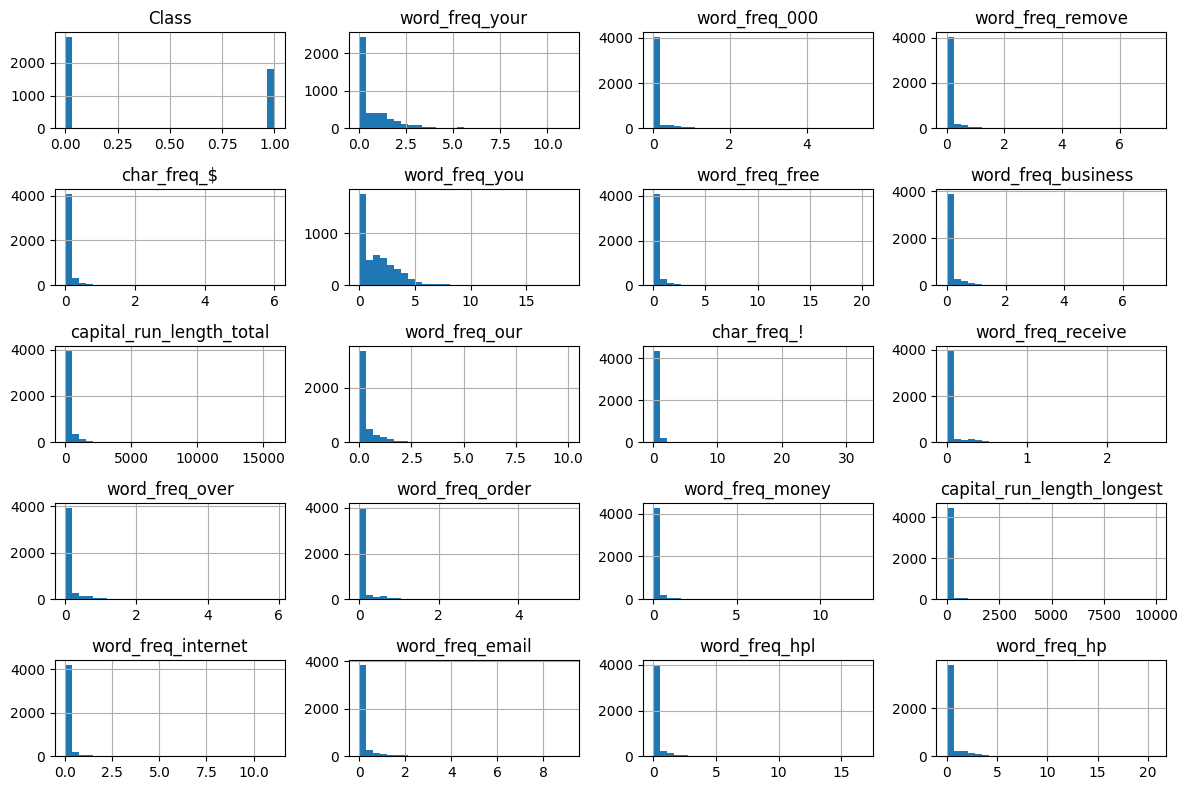

In [7]:


df1[selected_features].hist(figsize=(12,8), bins=30)

plt.tight_layout()
plt.show()

Vemos que la gran mayoría de variables muestran una distribución compatible con una ley de potencia


Distribución fuertemente sesgada con cola larga, compatible con transformación logarítmica

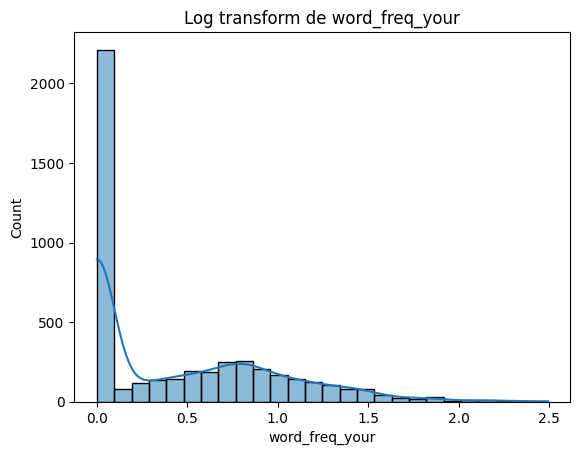

In [8]:
#Probamos a ver si de esta manera se vuelve mas simétrico el histograma
col = "word_freq_your"  # ejemplo

sns.histplot(np.log1p(df1[col]), kde=True)
plt.title(f"Log transform de {col}")
plt.show()

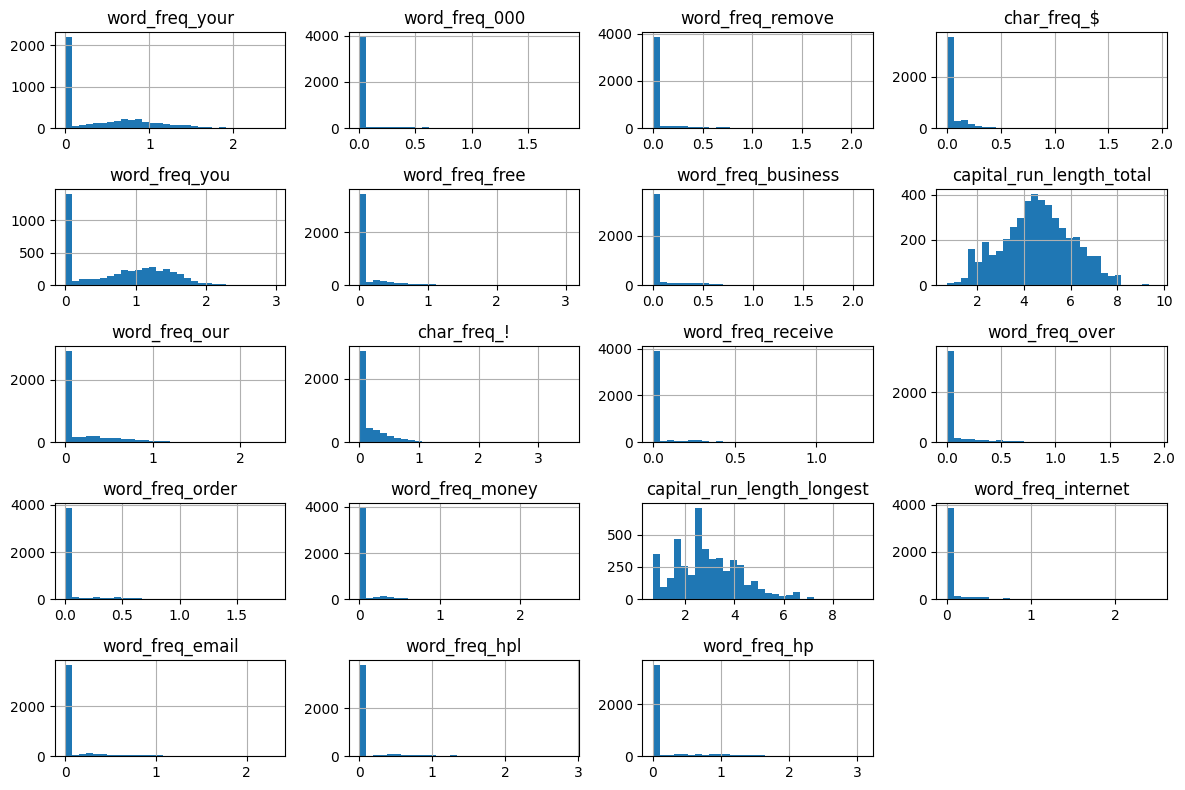

In [9]:

# Copia del dataframe para no perder el original
df_log = df1.copy()

# Aplicar log a todas las selected_features_model
for col in selected_features_model:
    df_log[col] = np.log1p(df_log[col])
    
df_log[selected_features_model].hist(figsize=(12,8), bins=30)

plt.tight_layout()
plt.show()

Tras aplicar una transformación logarítmica, se observa una reducción significativa de la asimetría en las variables, aunque se mantiene una concentración de valores cercanos a cero debido a la naturaleza de los datos.

Esta transformación mejora la distribución y facilita el entrenamiento de los modelos.

Ahora pasaremos a realizar una normalización mediante estandarización (Z-Score) para garantizar que todas las variables se encuentren en la misma escala.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df_log.copy()
df_scaled[selected_features_model] = scaler.fit_transform(df_log[selected_features_model])
df_scaled = df_scaled[selected_features]
df_scaled.head()

,Class,word_freq_your,word_freq_000,word_freq_remove,char_freq_$,word_freq_you,word_freq_free,word_freq_business,capital_run_length_total,word_freq_our,char_freq_!,word_freq_receive,word_freq_over,word_freq_order,word_freq_money,capital_run_length_longest,word_freq_internet,word_freq_email,word_freq_hpl,word_freq_hp
0,1,0.451350,-0.337218,-0.353590,-0.416852,0.469061,0.408411,-0.394323,0.704340,0.231557,1.359904,-0.335285,-0.407483,-0.363963,-0.326825,0.933656,-0.344176,2.547274,-0.38496,-0.460432
1,1,0.989779,1.405820,0.525164,0.737840,1.127002,-0.046099,-0.112497,1.566246,-0.204879,0.476987,1.041940,0.984364,-0.363963,1.539612,1.311604,-0.015161,0.462737,-0.38496,-0.460432
2,1,-0.052541,3.415714,0.448329,0.761448,0.132072,-0.271672,-0.151609,2.085832,1.792595,0.229914,1.991757,0.573301,2.366711,-0.022763,2.496859,0.206927,2.115395,-0.38496,-0.460432
3,1,-0.327022,-0.337218,0.891226,-0.416852,1.022518,0.384834,-0.394323,0.457538,0.859545,-0.162930,1.615652,-0.407483,1.126560,-0.326825,0.619688,2.031730,-0.421905,-0.38496,-0.460432
4,1,-0.327022,-0.337218,0.891226,-0.416852,1.022518,0.384834,-0.394323,0.457538,0.859545,-0.168927,1.615652,-0.407483,1.126560,-0.326825,0.619688,2.031730,-0.421905,-0.38496,-0.460432


Pasaremos ahora a dividir el dataset en dos conjuntos: el conjunto de prueba y el conjunto de entrenamiento.


In [11]:
from sklearn.model_selection import train_test_split

X = df_scaled.drop('Class', axis=1)  # tu target es "Class"
y = df_scaled['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y  # MUY IMPORTANTE
)

# comprobamos si tenemos un número proporcional de la variable class tanto en el conjunto de entrenamiento como en el de test. 
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Class
0    0.605901
1    0.394099
Name: proportion, dtype: float64
Class
0    0.606083
1    0.393917
Name: proportion, dtype: float64


El conjunto de datos se dividió en entrenamiento y prueba manteniendo la proporción de clases mediante estratificación. Se observa que ambas particiones presentan distribuciones muy similares, lo que garantiza una evaluación fiable del modelo.

Vamos a empezar ahora a aplicar distintos algoritmos en estos conjuntos de prueba y tests. 

# Regresión logística

In [12]:
from sklearn.linear_model import LogisticRegression

# crear modelo
log_model = LogisticRegression(max_iter=1000)

# entrenar
log_model.fit(X_train, y_train)

# predicciones
y_pred = log_model.predict(X_test)

Ahora comprobaremos la fiabilidad del modelo comprobando las métricas Accuracy, Precision, Recall, F1 score y la matriz de confusión.

In [13]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)

# accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# precision, recall, f1
print("Precisión:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# reporte completo
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9246922519913107
Precisión: 0.921455938697318
Recall: 0.8841911764705882
F1-score: 0.9024390243902439
Confusion Matrix:
 [[796  41]
 [ 63 481]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94       837
           1       0.92      0.88      0.90       544

    accuracy                           0.92      1381
   macro avg       0.92      0.92      0.92      1381
weighted avg       0.92      0.92      0.92      1381



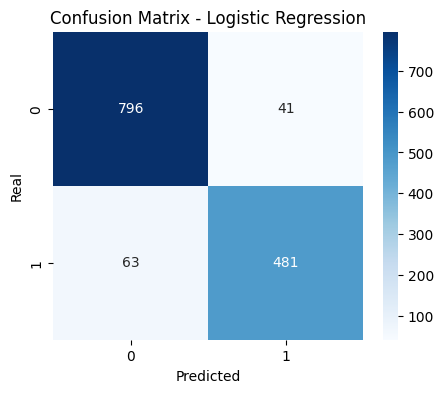

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Vemos que los resultados son bastante buenos, pero podríamos jugar con el umbral de clasificación para tratar de minimizar los falsos positivos que son los más preocupantes en estos casos de detección de spam. Para ello aumentaremos el umbral, haciendo que al clasificación de postivos sea más segura.

In [15]:
y_prob = log_model.predict_proba(X_test)[:,1]

# cambiar umbral
threshold = 0.7

y_pred_new = (y_prob >= threshold).astype(int)

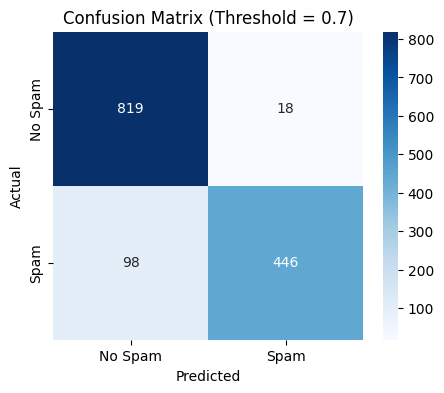

Accuracy: 0.9160028964518465
Precisión: 0.9612068965517241
Recall: 0.8198529411764706
F1 score: 0.8849206349206349


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# calcular matriz
cm07 = confusion_matrix(y_test, y_pred_new)

# graficar
plt.figure(figsize=(5,4))
sns.heatmap(cm07, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold = 0.7)")
plt.show()
print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("Precisión:", precision_score(y_test, y_pred_new)) 
print("Recall:", recall_score(y_test, y_pred_new))
print("F1 score:", f1_score(y_test, y_pred_new)) 

El ajuste del umbral de clasificación permite controlar el trade-off entre precisión y recall. Al incrementar el umbral a 0.7, el modelo exige mayor evidencia para clasificar una instancia como spam, lo que reduce significativamente los falsos positivos y mejora la precisión.

No obstante, este comportamiento también incrementa los falsos negativos, ya que algunos correos spam con menor probabilidad estimada no alcanzan el nuevo umbral.

En este contexto, dado que el coste de clasificar un correo legítimo como spam es elevado, el aumento de la precisión resulta especialmente relevante, justificando el uso de un umbral más alto.

# Árbol de clasificación.

In [17]:
from sklearn.tree import DecisionTreeClassifier

# modelo
tree_model = DecisionTreeClassifier(random_state=42)

# entrenar
tree_model.fit(X_train, y_train)

# predicciones
y_pred_tree = tree_model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precisión:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1-score:", f1_score(y_test, y_pred_tree))

cm_tree = confusion_matrix(y_test, y_pred_tree)
print(cm_tree)

Accuracy: 0.8928312816799421
Precisión: 0.8574007220216606
Recall: 0.8731617647058824
F1-score: 0.8652094717668488
[[758  79]
 [ 69 475]]


Visualizamos aquí la matriz de confusión

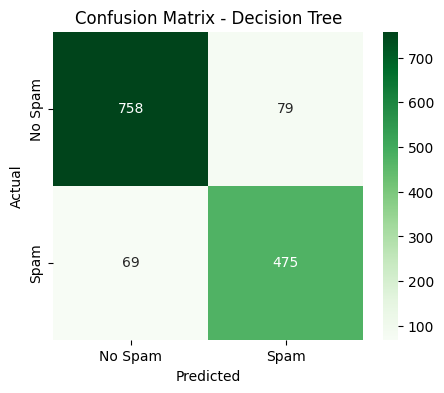

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, 
            annot=True, 
            fmt="d", 
            cmap="Greens",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

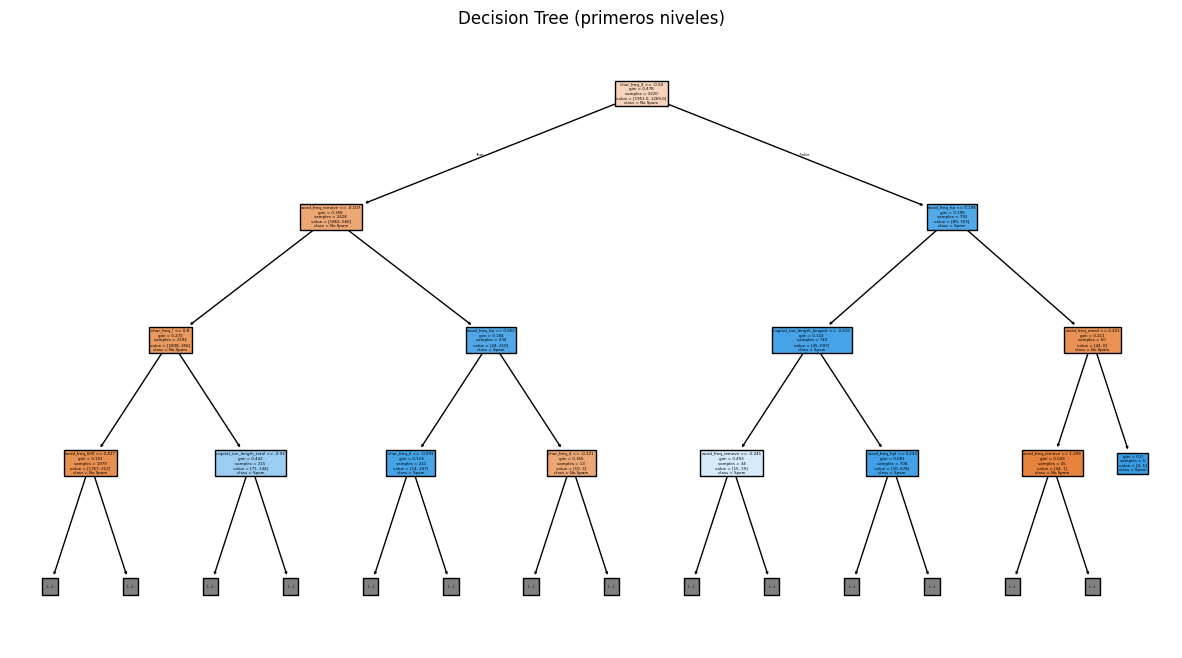

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,8))
plot_tree(tree_model, 
          feature_names=X_train.columns, 
          class_names=["No Spam", "Spam"],
          filled=True,
          max_depth=3)  # limitar profundidad para que se vea

plt.title("Decision Tree (primeros niveles)")
plt.show()

Trataremos ahora de implementar algunas mejoras al árbol de decisión.

In [21]:
classifier_improved = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=10,
    random_state=42
)

classifier_improved.fit(X_train, y_train)

y_pred_tree_improved = classifier_improved.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_tree_improved))
print("Precisión:", precision_score(y_test, y_pred_tree_improved))
print("Recall:", recall_score(y_test, y_pred_tree_improved))
print("F1-score:", f1_score(y_test, y_pred_tree_improved))

cm_tree_improved = confusion_matrix(y_test, y_pred_tree_improved)
print(cm_tree_improved)

Accuracy: 0.8848660391020999
Precisión: 0.8767123287671232
Recall: 0.8235294117647058
F1-score: 0.8492890995260663
[[774  63]
 [ 96 448]]


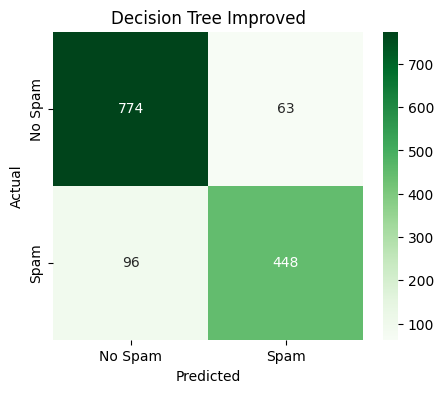

In [23]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_tree_improved, 
            annot=True, 
            fmt="d", 
            cmap="Greens",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])

plt.title("Decision Tree Improved")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Se ha introducido una restricción en el número mínimo de muestras necesarias para dividir un nodo con el objetivo de reducir el sobreajuste.

Esta modificación permite obtener un modelo más robusto, reduciendo errores en los datos de prueba y mejorando la capacidad de generalización.

Además se puede ver que de esta manera mejora la precisión y por tanto disminuimos el número de falsos positivos.

Por otro lado, la regresión logística con umbral ajustado presenta un mejor rendimiento en términos de precisión, reduciendo significativamente los falsos positivos.

Aunque el árbol de decisión obtiene un recall ligeramente superior, su elevado número de falsos positivos lo hace menos adecuado para este problema, donde es crítico evitar clasificar correos legítimos como spam.

# K-Nearest Neighbors (KNN)

In [24]:
from sklearn.neighbors import KNeighborsClassifier

# modelo (empezamos con k=5)
knn_model = KNeighborsClassifier(n_neighbors=5)

# entrenar
knn_model.fit(X_train, y_train)

# predicciones
y_pred_knn = knn_model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precisión:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

Accuracy: 0.9188993482983345
Precisión: 0.932
Recall: 0.8566176470588235
F1-score: 0.89272030651341
[[803  34]
 [ 78 466]]


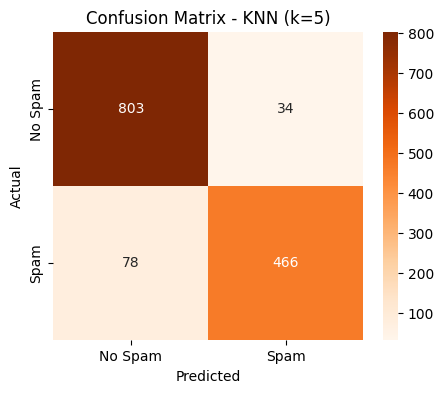

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, 
            annot=True, 
            fmt="d", 
            cmap="Oranges",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])

plt.title("Confusion Matrix - KNN (k=5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Se observa que el modelo KNN obtiene mejores resultados que el árbol de decisión, especialmente en términos de precisión y equilibrio general de métricas. Además, presenta un rendimiento similar al de la regresión logística sin ajuste de umbral.

No obstante, el rendimiento del modelo KNN depende en gran medida del número de vecinos considerados. Por este motivo, se realizarán diferentes pruebas variando el valor de k con el objetivo de identificar la configuración que proporcione el mejor equilibrio entre precisión y recall teniendo en cuenta que nuestra principal prioridad es minimizar la tasa de falsos positivos.

In [27]:
for k in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    print(f"K = {k}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precisión:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 score:", f1_score(y_test, y_pred))
    if k == 14:
        print("CM:",confusion_matrix(y_test, y_pred))

K = 1
Accuracy: 0.9044170890658942
Precisión: 0.8946360153256705
Recall: 0.8584558823529411
F1 score: 0.8761726078799249
K = 2
Accuracy: 0.9007965242577842
Precisión: 0.9552572706935123
Recall: 0.7849264705882353
F1 score: 0.8617558022199798
K = 3
Accuracy: 0.9196234612599565
Precisión: 0.9270216962524654
Recall: 0.8639705882352942
F1 score: 0.8943862987630827
K = 4
Accuracy: 0.9116582186821144
Precisión: 0.9527896995708155
Recall: 0.8161764705882353
F1 score: 0.8792079207920792
K = 5
Accuracy: 0.9188993482983345
Precisión: 0.932
Recall: 0.8566176470588235
F1 score: 0.89272030651341
K = 6
Accuracy: 0.9109341057204924
Precisión: 0.9507494646680942
Recall: 0.8161764705882353
F1 score: 0.8783382789317508
K = 7
Accuracy: 0.9217958001448225
Precisión: 0.943089430894309
Recall: 0.8529411764705882
F1 score: 0.8957528957528957
K = 8
Accuracy: 0.9145546705286025
Precisión: 0.9493670886075949
Recall: 0.8272058823529411
F1 score: 0.8840864440078585
K = 9
Accuracy: 0.9181752353367125
Precisión: 0.

Se observa que el valor k=14 proporciona la mayor precisión, lo que implica una reducción significativa de los falsos positivos. Sin embargo, este valor presenta un recall inferior a otras configuraciones como k=5 o k=9, donde se obtiene un mejor equilibrio entre precisión y recall.

Dado que en este problema es especialmente importante evitar falsos positivos, se selecciona k=14 como configuración óptima, aunque se reconoce el compromiso existente con la detección de todos los casos de spam. Se obtiene una precisión igual que la de regresión logística por lo que más adelante comprobaremos cual de los dos presenta mejores marcas.

# Support Vector Machine (SVM).

In [28]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

Accuracy: 0.9348298334540188
Precision: 0.9365384615384615
Recall: 0.8952205882352942
F1-score: 0.9154135338345865
[[804  33]
 [ 57 487]]


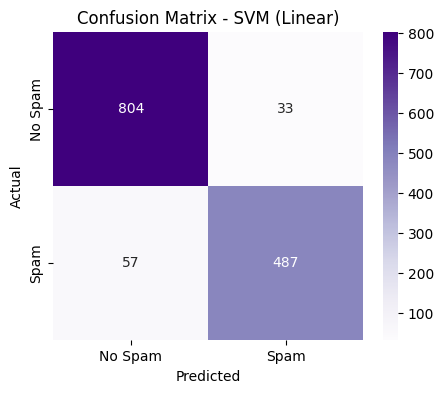

In [30]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, 
            annot=True, 
            fmt="d", 
            cmap="Purples",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])

plt.title("Confusion Matrix - SVM (Linear)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Se evalúa a continuación, el uso de un kernel no lineal (RBF) con el objetivo de analizar si una frontera de decisión más flexible mejora el rendimiento del modelo.

In [31]:
from sklearn.svm import SVC

svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm_rbf))
print("Precisión:", precision_score(y_test, y_pred_svm_rbf))
print("Recall:", recall_score(y_test, y_pred_svm_rbf))
print("F1 score:", f1_score(y_test,y_pred_svm_rbf))
print("CM:", confusion_matrix(y_test,y_pred_svm_rbf))

Accuracy: 0.9341057204923968
Precisión: 0.9364161849710982
Recall: 0.8933823529411765
F1 score: 0.9143932267168391
CM: [[804  33]
 [ 58 486]]


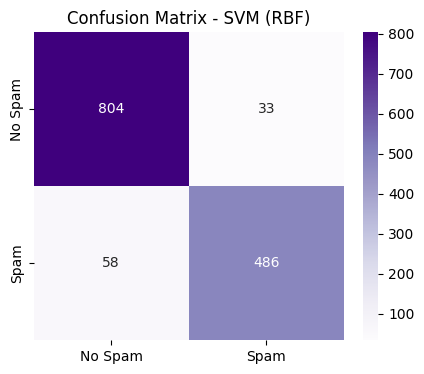

In [33]:
cm_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm_rbf, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])

plt.title("Confusion Matrix - SVM (RBF)")
plt.show()

El modelo SVM con kernel RBF no presenta una mejora en la precisión respecto al modelo lineal, lo que indica que la incorporación de una frontera de decisión no lineal, no permite capturar mejor las relaciones entre las variables.

Sin embargo, se observa una ligera disminución en el recall, lo que indica que algunos correos spam dejan de ser detectados.


# Red Neuronal (MLP)

In [34]:
from sklearn.neural_network import MLPClassifier

# modelo básico
nn_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)

# entrenar
nn_model.fit(X_train, y_train)

# predicciones
y_pred_nn = nn_model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precisión:", precision_score(y_test, y_pred_nn))
print("Recall:", recall_score(y_test, y_pred_nn))
print("F1-score:", f1_score(y_test, y_pred_nn))

cm_nn = confusion_matrix(y_test, y_pred_nn)
print(cm_nn)

Accuracy: 0.9304851556842868
Precisión: 0.9392156862745098
Recall: 0.8805147058823529
F1-score: 0.9089184060721063
[[806  31]
 [ 65 479]]


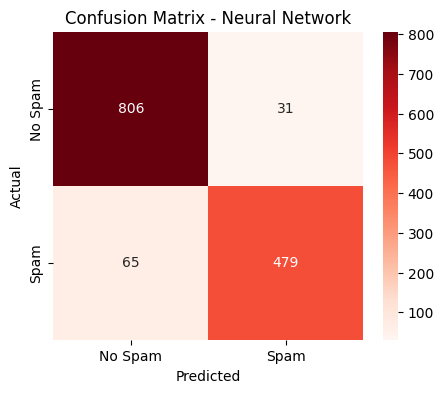

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm_nn, 
            annot=True, 
            fmt="d", 
            cmap="Reds",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])

plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Se ha aumentado la complejidad de la red neuronal añadiendo capas adicionales, con el objetivo de capturar patrones más complejos en los datos y mejorar el rendimiento del modelo.

In [37]:
nn_model_improved = MLPClassifier(
    hidden_layer_sizes=(100,50),
    max_iter=500,
    alpha=0.001,
    random_state=42
)

nn_model_improved.fit(X_train, y_train)

y_pred_nn_improved = nn_model_improved.predict(X_test)

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred_nn_improved))
print("Precisión:", precision_score(y_test, y_pred_nn_improved))
print("Recall:", recall_score(y_test, y_pred_nn_improved))
print("F1-score:", f1_score(y_test, y_pred_nn_improved))

cm_nn_improved = confusion_matrix(y_test, y_pred_nn_improved)
print(cm_nn_improved)

Accuracy: 0.9268645908761767
Precisión: 0.9124767225325885
Recall: 0.9007352941176471
F1-score: 0.906567992599445
[[790  47]
 [ 54 490]]


Se ha evaluado una versión más compleja de la red neuronal aumentando el número de capas ocultas. Sin embargo, los resultados muestran una disminución en la precisión, el recall y el F1-score, además de un aumento en los falsos positivos.

Esto sugiere que el incremento de complejidad no mejora el rendimiento del modelo, posiblemente debido a un sobreajuste o a que el problema no requiere una arquitectura tan compleja.

# Naive Bayes

In [39]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precisión:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1-score:", f1_score(y_test, y_pred_nb))

cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)

Accuracy: 0.9044170890658942
Precisión: 0.8976833976833977
Recall: 0.8547794117647058
F1-score: 0.8757062146892656
[[784  53]
 [ 79 465]]


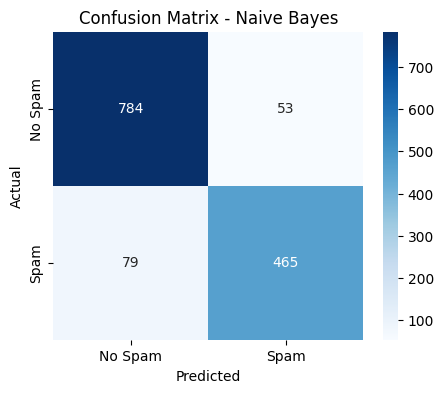

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

TABLA COMPARATIVA ENTRE MODELOS.
| Modelo                          | Accuracy | Precision | Recall | F1-score | FP | FN |
|---------------------------------|----------|-----------|--------|----------|----|----|
| Regresión Logística (0.7)       | 0.916    | 0.961     | 0.819  | 0.884    | 18 | 98 |
| Red Neuronal (base)             | 0.930    | 0.939     | 0.880  | 0.908    | 31 | 65 |
| SVM (RBF)                       | 0.934    | 0.936     | 0.893  | 0.914    | 33 | 58 |
| KNN (k=14)                      | 0.923    | 0.961     | 0.830  | 0.891    | 18 | 92 |
| SVM (linear)                    | 0.933    | 0.936     | 0.895  | 0.915    | 33 | 57 |
| Regresión Logística (0.5)       | 0.924    | 0.921     | 0.884  | 0.900    | 41 | 63 |
| KNN (k=5)                       | 0.918    | 0.932     | 0.850  | 0.890    | 34 | 78 |
| Red Neuronal (mejorada)         | 0.926    | 0.912     | 0.900  | 0.906    | 47 | 54 |
| Árbol de decisión               | 0.892    | 0.857     | 0.873  | 0.865    | 79 | 69 |
| Árbol de decisión (mejorado)    | 0.884    | 0.876     | 0.823  | 0.849    | 63 | 96 |
| Naive Bayes                     | 0.904    | 0.897     | 0.854  | 0.875    | 53 | 79 |

# Conclusión previa al PCA

En este trabajo se ha abordado un problema de clasificación binaria orientado a la detección de correos electrónicos spam, utilizando distintos modelos de aprendizaje automático sobre el conjunto de datos Spambase. A lo largo del análisis se ha realizado un proceso de preprocesado y exploración de datos que ha incluido el cálculo de estadísticos descriptivos, el estudio de correlaciones, la identificación de valores ausentes y posibles outliers, así como transformaciones de variables y normalización cuando ha sido necesario. Todo ello ha permitido comprender mejor la estructura del problema y preparar adecuadamente los datos para el entrenamiento de los modelos. 

En este contexto, la elección del mejor modelo no puede basarse únicamente en una métrica global de rendimiento. En un sistema real de filtrado de correo, los falsos positivos tienen un coste especialmente alto, ya que implican clasificar como spam correos legítimos que podrían contener información importante para el usuario. Por este motivo, en la comparación entre modelos se ha dado una importancia especial a la precisión y al control del número de falsos positivos, sin dejar de considerar el recall, el equilibrio global del modelo y su viabilidad práctica.

Los modelos evaluados han mostrado comportamientos diferentes. Naive Bayes destaca por su capacidad para detectar una gran proporción de correos spam, pero genera demasiados falsos positivos, lo que limita su utilidad práctica en este problema. Los árboles de decisión presentan la ventaja de ser muy interpretables, ya que permiten representar reglas de decisión de forma clara, aunque su rendimiento ha sido inferior al de otros modelos y muestran una mayor sensibilidad al error. KNN y SVM ofrecen resultados competitivos desde el punto de vista predictivo, pero presentan un mayor coste computacional y una interpretabilidad menor, especialmente en comparación con modelos lineales o árboles simples. La red neuronal base obtiene un comportamiento equilibrado y confirma que el problema puede resolverse con modelos no lineales; sin embargo, al incrementar su complejidad no se observa una mejora clara, lo que sugiere que aumentar la sofisticación del modelo no siempre produce beneficios reales en este conjunto de datos.

Desde el punto de vista de la interpretabilidad, la regresión logística y el árbol de decisión son los modelos más favorables, ya que permiten entender mejor qué variables influyen en la clasificación. Esto es especialmente relevante en un trabajo como este, donde no solo importa predecir correctamente, sino también justificar por qué un modelo puede ser preferible a otro. En términos de interés práctico, los modelos más útiles son aquellos que combinan buen rendimiento con estabilidad, facilidad de aplicación y bajo riesgo de errores críticos. Desde esta perspectiva, no basta con detectar mucho spam; es necesario hacerlo sin comprometer la recepción de correos legítimos.

En cuanto a la novedad, ninguno de los modelos utilizados es especialmente novedoso desde un punto de vista metodológico, ya que se trata de algoritmos clásicos y ampliamente conocidos en aprendizaje automático. No obstante, su interés dentro del proyecto radica precisamente en permitir una comparación sólida entre enfoques de distinta naturaleza: modelos lineales, basados en distancia, basados en márgenes, probabilísticos, árboles y redes neuronales. Esta comparación aporta valor porque permite observar cómo cambia el equilibrio entre rendimiento, complejidad e interpretabilidad según el tipo de modelo empleado.

Respecto al coste estimado de aplicación, también existen diferencias importantes. Modelos como la regresión logística y Naive Bayes presentan un coste bajo tanto en entrenamiento como en inferencia, lo que los hace adecuados para sistemas que requieren rapidez y escalabilidad. Los árboles de decisión también tienen un coste razonable y una implementación sencilla. Por el contrario, KNN presenta un coste de predicción más elevado, ya que necesita comparar cada nuevo ejemplo con el conjunto de entrenamiento, mientras que SVM y redes neuronales suelen requerir un ajuste más costoso y una interpretación menos directa. En un entorno real, donde el modelo debe aplicarse de forma continua sobre grandes volúmenes de correo, este factor es relevante.

A partir de la comparación conjunta de precisión, recall, interpretabilidad, interés práctico, novedad y coste de aplicación, la regresión logística con umbral ajustado a 0.7, junto con KNN (k=14),se consideran la opción más adecuada para este problema. Aunque no maximizan el recall, ofrecen la mayor precisión y reducen de forma notable los falsos positivos, que son el error más costoso en este contexto. 



## Validación del modelo con mejores resultados obtenidos (Regresión logística (umbral = 0.7)).

In [42]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score

# modelo
model = LogisticRegression(max_iter=1000)

# validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

precision_scores = []
recall_scores = []

for train_index, test_index in skf.split(X, y):
    
    # dividir datos
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
    
    # entrenar modelo
    model.fit(X_train_cv, y_train_cv)
    
    # probabilidades
    y_prob = model.predict_proba(X_test_cv)[:, 1]
    
    # aplicar umbral 0.7
    y_pred = (y_prob >= 0.7).astype(int)
    
    # métricas
    precision_scores.append(precision_score(y_test_cv, y_pred))
    recall_scores.append(recall_score(y_test_cv, y_pred))

# resultados finales
print("Precisión por fold:", precision_scores)
print("Precisión media:", np.mean(precision_scores))

print("\nRecall por fold:", recall_scores)
print("Recall medio:", np.mean(recall_scores))

Precisión por fold: [0.9595959595959596, 0.9493670886075949, 0.941358024691358, 0.9423076923076923, 0.9627118644067797]
Precisión media: 0.951068125921877

Recall por fold: [0.7851239669421488, 0.8264462809917356, 0.8402203856749312, 0.8121546961325967, 0.7845303867403315]
Recall medio: 0.8096951432963488


Ahora hacemos o mismo para KNN (k=14)

In [43]:
# modelo KNN con k=14
model = KNeighborsClassifier(n_neighbors=14)

# validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

precision_scores = []
recall_scores = []

for train_index, test_index in skf.split(X, y):
    
    # dividir datos
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
    
    # entrenar modelo
    model.fit(X_train_cv, y_train_cv)
    
    # predicciones
    y_pred = model.predict(X_test_cv)
    
    # métricas
    precision_scores.append(precision_score(y_test_cv, y_pred))
    recall_scores.append(recall_score(y_test_cv, y_pred))

# resultados finales
print("Precisión por fold:", precision_scores)
print("Precisión media:", np.mean(precision_scores))

print("\nRecall por fold:", recall_scores)
print("Recall medio:", np.mean(recall_scores))

Precisión por fold: [0.953125, 0.950920245398773, 0.950920245398773, 0.9329073482428115, 0.9369085173501577]
Precisión media: 0.9449562712781031

Recall por fold: [0.8402203856749312, 0.8539944903581267, 0.8539944903581267, 0.8066298342541437, 0.8204419889502762]
Recall medio: 0.8350562379191209


Se ha aplicado validación cruzada estratificada para evaluar la robustez del modelo de regresión logística con umbral ajustado a 0.7 y de KNN (k=14).

Los resultados obtenidos muestran una precisión media de 0.951, con muy poca variabilidad entre las distintas particiones, lo que indica que el modelo mantiene de forma consistente un bajo número de falsos positivos.

Por otro lado, KNN muestra una precisión media ligeramente inferior por lo que la regresión logística cn el umbral ajustado sigue siendo nuestra mejor opción.

En conjunto, estos resultados confirman que el modelo no depende de una única división de los datos y presenta un comportamiento estable y generalizable.

## Backup


Se implementa un **pipeline de backup** que sustituye la selección de variables por correlación de Pearson por una reducción de dimensionalidad mediante **Análisis de Componentes Principales (PCA)**.

El proceso sigue el mismo orden que el pipeline original:
1. Carga del dataset (mismo `df1` antes del filtro de correlación)
2. Aplicación de PCA para crear un nuevo DataFrame con las componentes principales
3. Transformación logarítmica, normalización, train/test split
4. Entrenamiento y evaluación con los mismos modelos y configuraciones

## Feature Engineering con PCA

En lugar de seleccionar variables mediante el umbral de correlación de Pearson, aplicamos PCA directamente sobre **todas las variables** del dataset original.

Seguimos el mismo patrón del notebook de referencia (`2_data_transformation.ipynb`):
- Separar features de la variable objetivo
- Estandarizar con `StandardScaler` **antes** de aplicar PCA (paso obligatorio)
- Aplicar PCA conservando el **95% de la varianza** como punto de partida
- Construir el DataFrame de componentes principales y concatenar con la clase

> **¿Por qué estandarizar antes?** PCA es sensible a la escala de las variables. Sin estandarización, las variables con mayor rango dominarían las componentes.

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Separar features de la clase — usamos el df1 completo, sin filtro de correlación
X_all = df1.drop('Class', axis=1)
y_all = df1['Class']

# Estandarizar las features (obligatorio antes de PCA)
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_all)

# Aplicar PCA conservando el 95% de la varianza
pca = PCA(0.95)
principalComponents = pca.fit_transform(X_scaled_pca)

print(f"Número de componentes retenidas (95% varianza): {pca.n_components_}")
print(f"Variables originales: {X_all.shape[1]}")
print(f"Reducción: {X_all.shape[1]} → {pca.n_components_} componentes")

Número de componentes retenidas (95% varianza): 48
Variables originales: 57
Reducción: 57 → 48 componentes


Visualizamos cuánta varianza acumula cada componente para entender la distribución de la información.

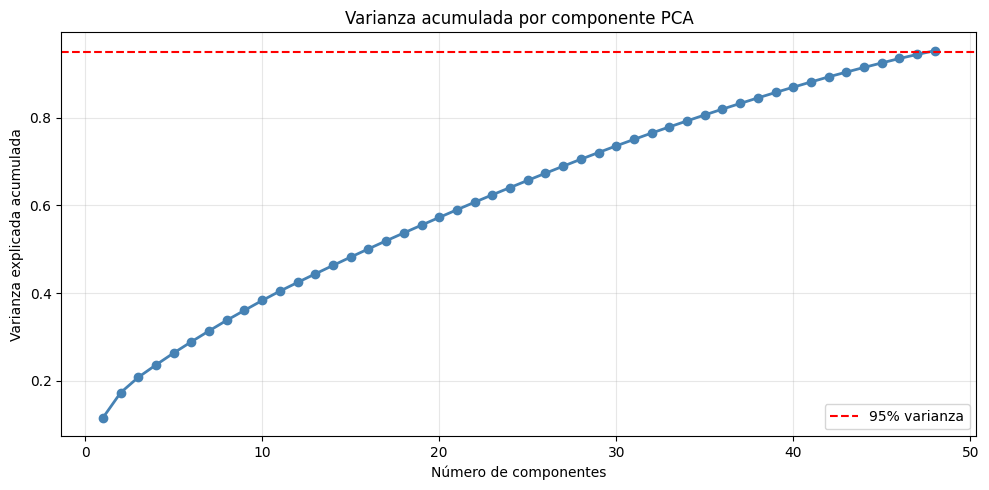

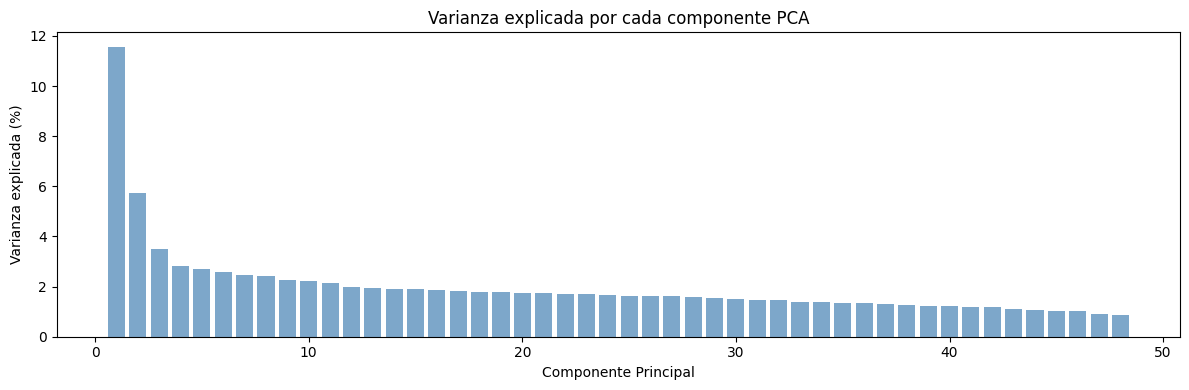

In [45]:
# Varianza explicada acumulada
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linewidth=2, color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% varianza')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza acumulada por componente PCA")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Varianza individual por componente
plt.figure(figsize=(12, 4))
plt.bar(range(1, pca.n_components_ + 1), pca.explained_variance_ratio_ * 100, color='steelblue', alpha=0.7)
plt.xlabel("Componente Principal")
plt.ylabel("Varianza explicada (%)")
plt.title("Varianza explicada por cada componente PCA")
plt.tight_layout()
plt.show()

Construimos el DataFrame con las componentes PCA y lo concatenamos con la variable objetivo

In [46]:
# Construir DataFrame de componentes PCA
column_names = [f'PC{i+1}' for i in range(pca.n_components_)]
pcaDf = pd.DataFrame(data=principalComponents, columns=column_names)

# Concatenar con la clase (equivalente al finalDf del notebook de referencia)
df_pca = pd.concat([pcaDf, y_all.reset_index(drop=True)], axis=1)

print(f"Shape del nuevo DataFrame PCA: {df_pca.shape}")
df_pca.head()

Shape del nuevo DataFrame PCA: (4601, 49)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,Class
0,-0.731750,-0.043026,-0.580662,-0.251143,-0.174836,-0.569760,0.050593,0.071795,0.415564,-0.809260,...,0.328918,-0.025611,0.072388,0.682891,0.052138,-0.162968,-0.208357,0.143936,0.339344,1
1,-1.185084,2.067850,0.036035,0.430459,-0.327619,-0.826688,0.490183,0.621681,-0.883679,0.351408,...,-0.163981,0.288200,0.378792,0.230267,0.139854,-0.156299,0.291900,-0.141545,0.262410,1
2,-1.467595,5.023754,3.277591,0.995065,0.641304,-2.784683,1.844471,-2.097819,1.982749,0.259473,...,-1.672497,0.280127,0.052592,-0.394560,-0.709672,0.295599,-0.079436,-0.625527,-1.131376,1
3,-0.805347,0.427503,-0.583107,-0.008242,-0.077464,0.547862,-0.404900,-0.459410,0.160853,0.260453,...,-1.088386,-0.382526,-0.278213,-0.467940,0.216300,-0.238498,-0.840444,0.410776,0.107400,1
4,-0.806279,0.426747,-0.585155,-0.008167,-0.077655,0.547753,-0.403780,-0.461120,0.160601,0.261989,...,-1.087952,-0.382583,-0.276466,-0.466795,0.216558,-0.238331,-0.840652,0.409227,0.106594,1


Visualizamos las dos primeras componentes principales separadas por clase para ver si PCA logra una separación útil entre spam y no spam.

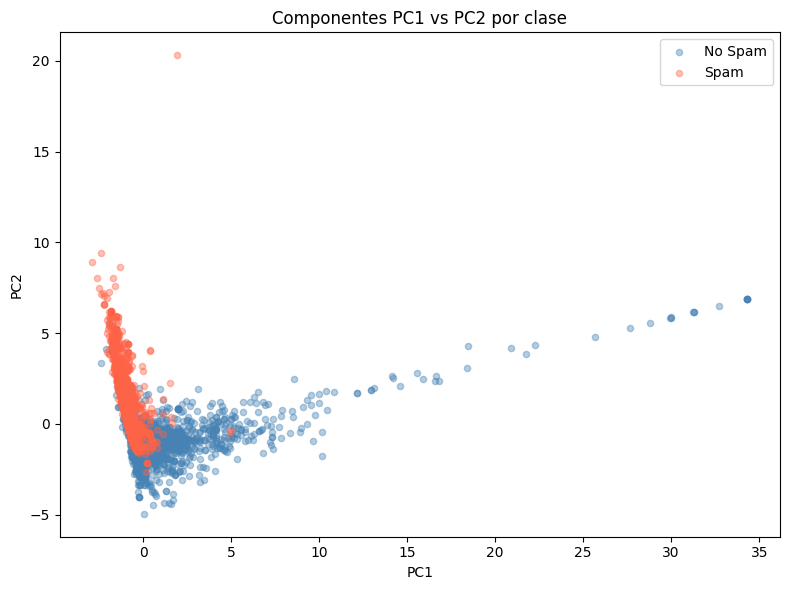

In [47]:
# Scatter plot PC1 vs PC2 coloreado por clase
plt.figure(figsize=(8, 6))
colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'No Spam', 1: 'Spam'}

for clase in [0, 1]:
    mask = df_pca['Class'] == clase
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                c=colors[clase], label=labels[clase], alpha=0.4, s=20)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Componentes PC1 vs PC2 por clase")
plt.legend()
plt.tight_layout()
plt.show()

## Detección de outliers y transformación logarítmica

Aunque PCA ya suaviza el impacto de los outliers al proyectar en nuevos ejes, las componentes pueden seguir presentando distribuciones asimétricas. Comprobamos la distribución de las componentes y aplicamos log1p si es necesario.

In [48]:
# Detección de outliers en las componentes PCA mediante IQR
Q1 = pcaDf.quantile(0.25)
Q3 = pcaDf.quantile(0.75)
IQR = Q3 - Q1

outliers_pca = ((pcaDf < (Q1 - 1.5 * IQR)) | (pcaDf > (Q3 + 1.5 * IQR)))
print("Outliers por componente PCA:")
print(outliers_pca.sum())

Outliers por componente PCA:
PC1     489
PC2     206
PC3     258
PC4     420
PC5     347
PC6     512
PC7     439
PC8     230
PC9     377
PC10    370
PC11    243
PC12    276
PC13    386
PC14    281
PC15    288
PC16    535
PC17    391
PC18    535
PC19    362
PC20    437
PC21    327
PC22    355
PC23    368
PC24    477
PC25    401
PC26    431
PC27    264
PC28    309
PC29    390
PC30    326
PC31    308
PC32    353
PC33    241
PC34    351
PC35    312
PC36    276
PC37    196
PC38    154
PC39    318
PC40    345
PC41    276
PC42    250
PC43    308
PC44    161
PC45    344
PC46    359
PC47    362
PC48    405
dtype: int64


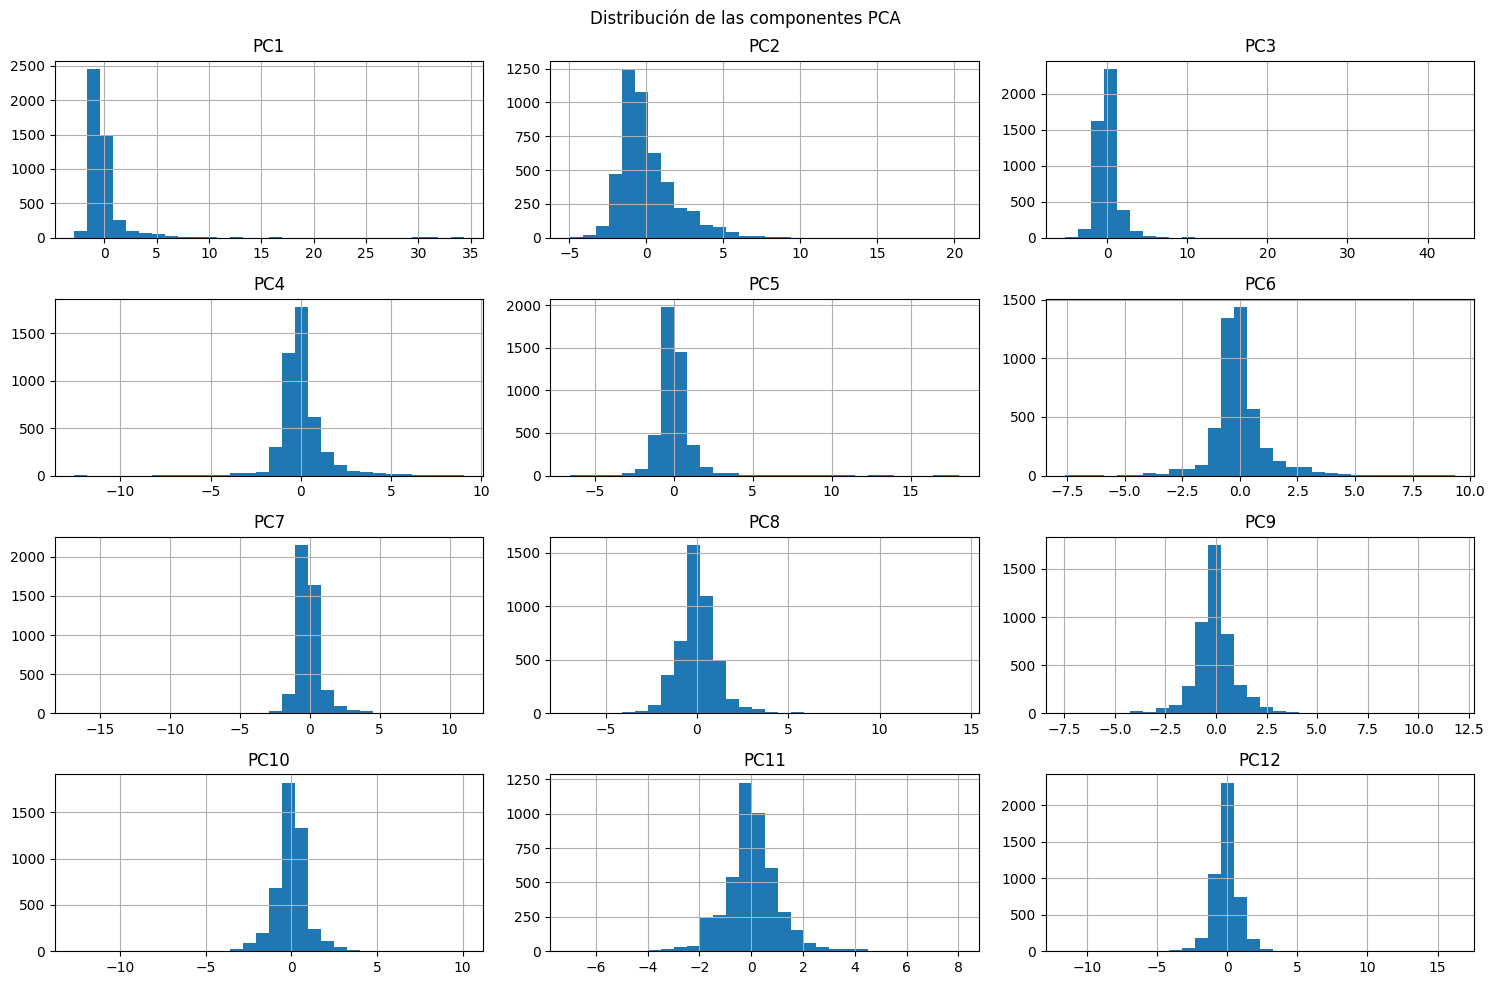

In [49]:
# Histogramas de las primeras componentes PCA
n_cols = min(pca.n_components_, 12)  # mostramos máx. 12 para claridad visual
pcaDf.iloc[:, :n_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribución de las componentes PCA")
plt.tight_layout()
plt.show()

## División Train / Test

Dividimos con la misma configuración que en el pipeline original: 70% entrenamiento, 30% test, con estratificación para mantener la proporción de clases.

In [50]:
from sklearn.model_selection import train_test_split

X_pca = df_pca.drop('Class', axis=1)
y_pca = df_pca['Class']

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y_pca,
    test_size=0.3,
    random_state=42,
    stratify=y_pca
)

print("Proporción de clases en entrenamiento:")
print(y_train_pca.value_counts(normalize=True))
print("\nProporción de clases en test:")
print(y_test_pca.value_counts(normalize=True))

Proporción de clases en entrenamiento:
Class
0    0.605901
1    0.394099
Name: proportion, dtype: float64

Proporción de clases en test:
Class
0    0.606083
1    0.393917
Name: proportion, dtype: float64


## 6. Modelos de clasificación

A partir de aquí reproducimos exactamente el mismo orden de modelos y configuraciones que en el pipeline original.

---

### 6.1 Regresión Logística

=== Regresión Logística (umbral 0.5) ===
Accuracy: 0.9283128167994207
Precisión: 0.9238095238095239
Recall: 0.8915441176470589
F1-score: 0.9073900841908326


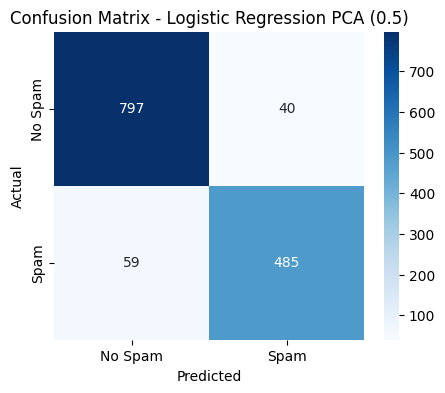

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Modelo base (umbral 0.5)
log_model_pca = LogisticRegression(max_iter=1000)
log_model_pca.fit(X_train_pca, y_train_pca)
y_pred_log_pca = log_model_pca.predict(X_test_pca)

print("=== Regresión Logística (umbral 0.5) ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_log_pca))
print("Precisión:", precision_score(y_test_pca, y_pred_log_pca))
print("Recall:", recall_score(y_test_pca, y_pred_log_pca))
print("F1-score:", f1_score(y_test_pca, y_pred_log_pca))

cm_log_pca = confusion_matrix(y_test_pca, y_pred_log_pca)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log_pca, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression PCA (0.5)")
plt.show()

=== Regresión Logística (umbral 0.7) ===
Accuracy: 0.9015206372194062
Precisión: 0.9493392070484582
Recall: 0.7922794117647058
F1-score: 0.8637274549098196


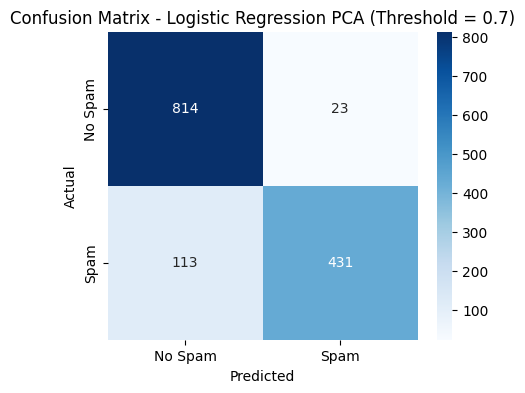

In [52]:
# Umbral ajustado a 0.7 (mismo que en el pipeline original)
y_prob_log_pca = log_model_pca.predict_proba(X_test_pca)[:, 1]
threshold = 0.7
y_pred_log_pca_07 = (y_prob_log_pca >= threshold).astype(int)

print("=== Regresión Logística (umbral 0.7) ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_log_pca_07))
print("Precisión:", precision_score(y_test_pca, y_pred_log_pca_07))
print("Recall:", recall_score(y_test_pca, y_pred_log_pca_07))
print("F1-score:", f1_score(y_test_pca, y_pred_log_pca_07))

cm_log_pca_07 = confusion_matrix(y_test_pca, y_pred_log_pca_07)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log_pca_07, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression PCA (Threshold = 0.7)")
plt.show()

## Árbol de clasificación

=== Árbol de Decisión (base) ===
Accuracy: 0.8841419261404779
Precisión: 0.8404255319148937
Recall: 0.8713235294117647
F1-score: 0.855595667870036


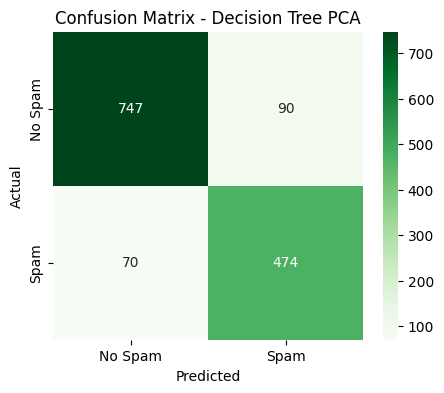

In [53]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Árbol base
tree_model_pca = DecisionTreeClassifier(random_state=42)
tree_model_pca.fit(X_train_pca, y_train_pca)
y_pred_tree_pca = tree_model_pca.predict(X_test_pca)

print("=== Árbol de Decisión (base) ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_tree_pca))
print("Precisión:", precision_score(y_test_pca, y_pred_tree_pca))
print("Recall:", recall_score(y_test_pca, y_pred_tree_pca))
print("F1-score:", f1_score(y_test_pca, y_pred_tree_pca))

cm_tree_pca = confusion_matrix(y_test_pca, y_pred_tree_pca)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree_pca, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree PCA")
plt.show()

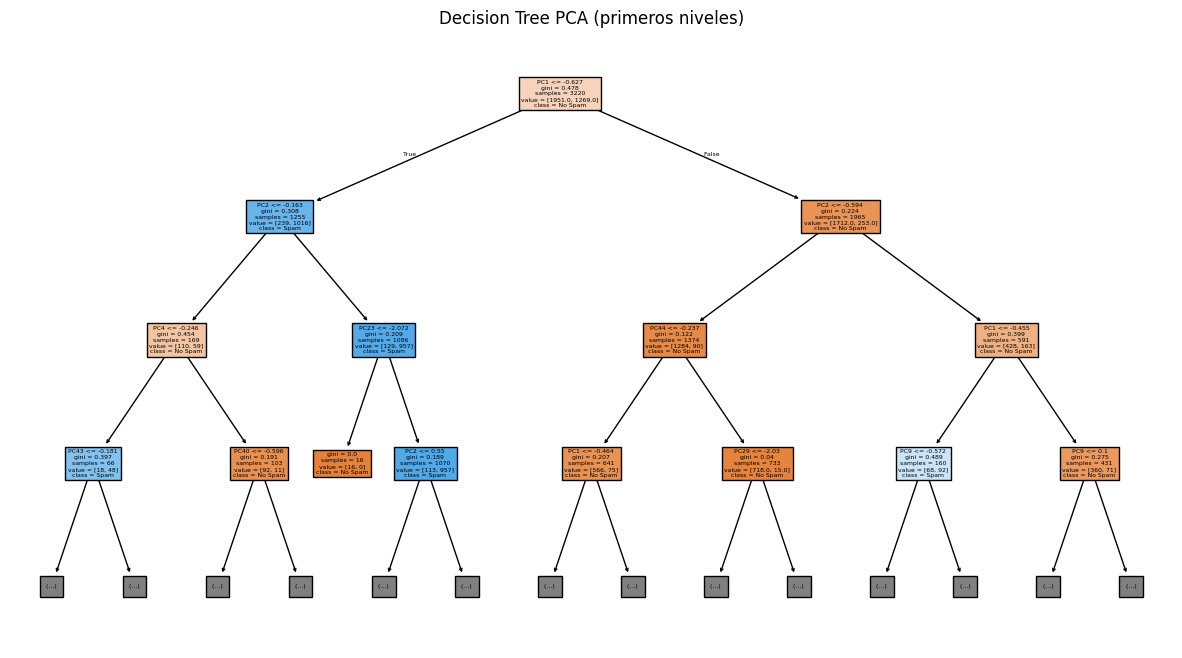

In [54]:
# Visualización del árbol (primeros niveles)
plt.figure(figsize=(15, 8))
plot_tree(tree_model_pca,
          feature_names=X_train_pca.columns,
          class_names=["No Spam", "Spam"],
          filled=True,
          max_depth=3)
plt.title("Decision Tree PCA (primeros niveles)")
plt.show()

=== Árbol de Decisión Mejorado ===
Accuracy: 0.8863142650253439
Precisión: 0.8365217391304348
Recall: 0.8841911764705882
F1-score: 0.8596961572832886


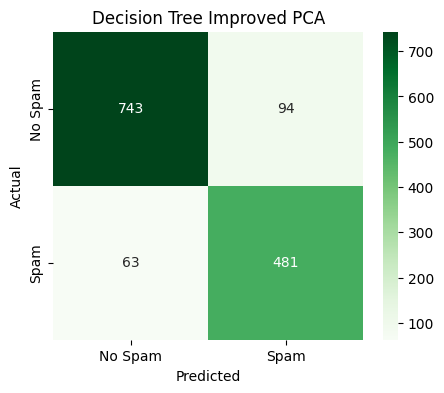

In [55]:
# Árbol mejorado (mismo criterio que en el pipeline original)
tree_model_pca_improved = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=10,
    random_state=42
)
tree_model_pca_improved.fit(X_train_pca, y_train_pca)
y_pred_tree_pca_improved = tree_model_pca_improved.predict(X_test_pca)

print("=== Árbol de Decisión Mejorado ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_tree_pca_improved))
print("Precisión:", precision_score(y_test_pca, y_pred_tree_pca_improved))
print("Recall:", recall_score(y_test_pca, y_pred_tree_pca_improved))
print("F1-score:", f1_score(y_test_pca, y_pred_tree_pca_improved))

cm_tree_pca_improved = confusion_matrix(y_test_pca, y_pred_tree_pca_improved)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree_pca_improved, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.title("Decision Tree Improved PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### K-Nearest Neighbors (KNN)

=== KNN (k=5) ===
Accuracy: 0.9015206372194062
Precisión: 0.8820224719101124
Recall: 0.8658088235294118
F1-score: 0.8738404452690167


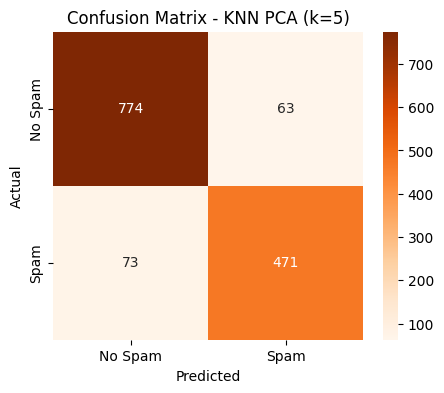

In [56]:
from sklearn.neighbors import KNeighborsClassifier

# KNN base (k=5)
knn_model_pca = KNeighborsClassifier(n_neighbors=5)
knn_model_pca.fit(X_train_pca, y_train_pca)
y_pred_knn_pca = knn_model_pca.predict(X_test_pca)

print("=== KNN (k=5) ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_knn_pca))
print("Precisión:", precision_score(y_test_pca, y_pred_knn_pca))
print("Recall:", recall_score(y_test_pca, y_pred_knn_pca))
print("F1-score:", f1_score(y_test_pca, y_pred_knn_pca))

cm_knn_pca = confusion_matrix(y_test_pca, y_pred_knn_pca)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn_pca, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.title("Confusion Matrix - KNN PCA (k=5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [57]:
# Búsqueda del k óptimo (mismo rango que en el pipeline original)
for k in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pca, y_train_pca)
    y_pred = knn.predict(X_test_pca)

    print(f"K = {k}")
    print("Accuracy:", accuracy_score(y_test_pca, y_pred))
    print("Precisión:", precision_score(y_test_pca, y_pred))
    print("Recall:", recall_score(y_test_pca, y_pred))
    print("F1 score:", f1_score(y_test_pca, y_pred))
    if k == 8:
        print("CM:", confusion_matrix(y_test_pca, y_pred))

K = 1
Accuracy: 0.8964518464880521
Precisión: 0.8652094717668488
Recall: 0.8731617647058824
F1 score: 0.869167429094236
K = 2
Accuracy: 0.8870383779869659
Precisión: 0.9145299145299145
Recall: 0.7867647058823529
F1 score: 0.8458498023715415
K = 3
Accuracy: 0.9000724112961622
Precisión: 0.878731343283582
Recall: 0.8658088235294118
F1 score: 0.8722222222222222
K = 4
Accuracy: 0.8964518464880521
Precisión: 0.9083503054989817
Recall: 0.8198529411764706
F1 score: 0.8618357487922705
K = 5
Accuracy: 0.9015206372194062
Precisión: 0.8820224719101124
Recall: 0.8658088235294118
F1 score: 0.8738404452690167
K = 6
Accuracy: 0.9036929761042722
Precisión: 0.906930693069307
Recall: 0.8419117647058824
F1 score: 0.8732125834127741
K = 7
Accuracy: 0.9058653149891384
Precisión: 0.8920454545454546
Recall: 0.8658088235294118
F1 score: 0.878731343283582
K = 8
Accuracy: 0.9073135409123824
Precisión: 0.9110671936758893
Recall: 0.8474264705882353
F1 score: 0.878095238095238
CM: [[792  45]
 [ 83 461]]
K = 9
Accu

### SVM


=== SVM (Linear) ===
Accuracy: 0.9254163649529327
Precisión: 0.9152542372881356
Recall: 0.8933823529411765
F1-score: 0.9041860465116279


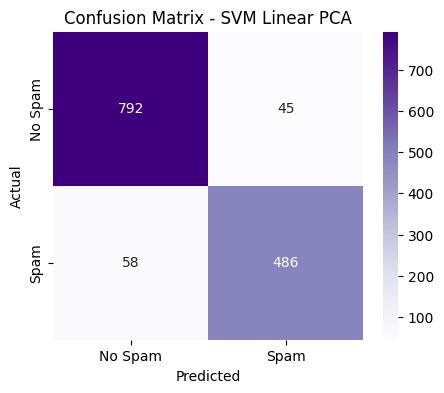

In [58]:
from sklearn.svm import SVC

# SVM kernel lineal
svm_model_pca = SVC(kernel='linear')
svm_model_pca.fit(X_train_pca, y_train_pca)
y_pred_svm_pca = svm_model_pca.predict(X_test_pca)

print("=== SVM (Linear) ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_svm_pca))
print("Precisión:", precision_score(y_test_pca, y_pred_svm_pca))
print("Recall:", recall_score(y_test_pca, y_pred_svm_pca))
print("F1-score:", f1_score(y_test_pca, y_pred_svm_pca))

cm_svm_pca = confusion_matrix(y_test_pca, y_pred_svm_pca)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm_pca, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.title("Confusion Matrix - SVM Linear PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== SVM (RBF) ===
Accuracy: 0.9268645908761767
Precisión: 0.9251439539347409
Recall: 0.8860294117647058
F1 score: 0.9051643192488263


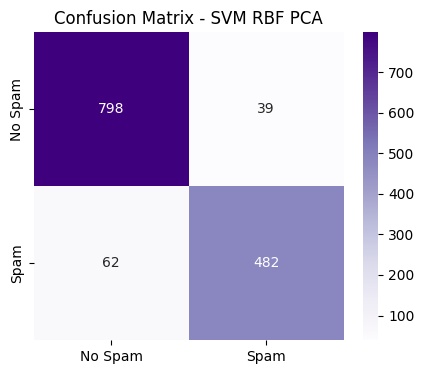

In [59]:
# SVM kernel RBF
svm_rbf_pca = SVC(kernel='rbf')
svm_rbf_pca.fit(X_train_pca, y_train_pca)
y_pred_svm_rbf_pca = svm_rbf_pca.predict(X_test_pca)

print("=== SVM (RBF) ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_svm_rbf_pca))
print("Precisión:", precision_score(y_test_pca, y_pred_svm_rbf_pca))
print("Recall:", recall_score(y_test_pca, y_pred_svm_rbf_pca))
print("F1 score:", f1_score(y_test_pca, y_pred_svm_rbf_pca))

cm_svm_rbf_pca = confusion_matrix(y_test_pca, y_pred_svm_rbf_pca)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm_rbf_pca, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.title("Confusion Matrix - SVM RBF PCA")
plt.show()

### Red neuronal

=== Red Neuronal (base) ===
Accuracy: 0.942070963070239
Precisión: 0.9328358208955224
Recall: 0.9191176470588235
F1-score: 0.9259259259259259


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


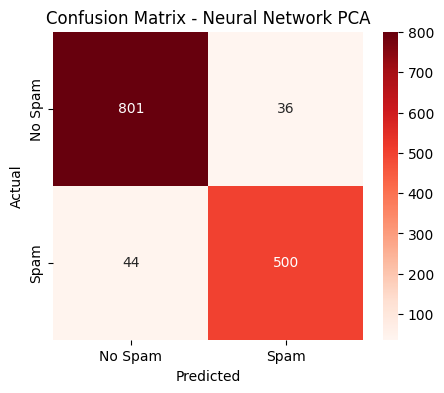

In [60]:
from sklearn.neural_network import MLPClassifier

# Red neuronal base
nn_model_pca = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
nn_model_pca.fit(X_train_pca, y_train_pca)
y_pred_nn_pca = nn_model_pca.predict(X_test_pca)

print("=== Red Neuronal (base) ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_nn_pca))
print("Precisión:", precision_score(y_test_pca, y_pred_nn_pca))
print("Recall:", recall_score(y_test_pca, y_pred_nn_pca))
print("F1-score:", f1_score(y_test_pca, y_pred_nn_pca))

cm_nn_pca = confusion_matrix(y_test_pca, y_pred_nn_pca)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nn_pca, annot=True, fmt="d", cmap="Reds",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.title("Confusion Matrix - Neural Network PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
# Red neuronal mejorada (misma arquitectura que en el pipeline original)
nn_model_pca_improved = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    alpha=0.001,
    random_state=42
)
nn_model_pca_improved.fit(X_train_pca, y_train_pca)
y_pred_nn_pca_improved = nn_model_pca_improved.predict(X_test_pca)

print("=== Red Neuronal Mejorada ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_nn_pca_improved))
print("Precisión:", precision_score(y_test_pca, y_pred_nn_pca_improved))
print("Recall:", recall_score(y_test_pca, y_pred_nn_pca_improved))
print("F1-score:", f1_score(y_test_pca, y_pred_nn_pca_improved))

cm_nn_pca_improved = confusion_matrix(y_test_pca, y_pred_nn_pca_improved)
print("CM:", cm_nn_pca_improved)

=== Red Neuronal Mejorada ===
Accuracy: 0.946415640839971
Precisión: 0.933579335793358
Recall: 0.9301470588235294
F1-score: 0.9318600368324125
CM: [[801  36]
 [ 38 506]]


### Naive Bayes


=== Naive Bayes ===
Accuracy: 0.8711078928312816
Precisión: 0.8009868421052632
Recall: 0.8952205882352942
F1-score: 0.8454861111111112


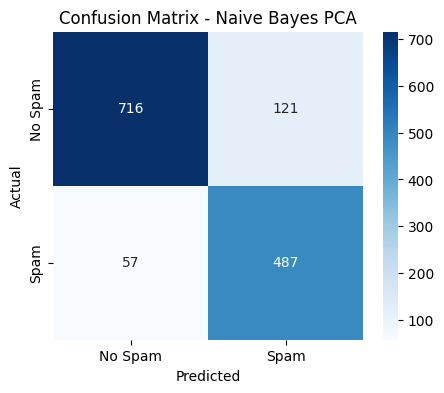

In [62]:
from sklearn.naive_bayes import GaussianNB

nb_model_pca = GaussianNB()
nb_model_pca.fit(X_train_pca, y_train_pca)
y_pred_nb_pca = nb_model_pca.predict(X_test_pca)

print("=== Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_nb_pca))
print("Precisión:", precision_score(y_test_pca, y_pred_nb_pca))
print("Recall:", recall_score(y_test_pca, y_pred_nb_pca))
print("F1-score:", f1_score(y_test_pca, y_pred_nb_pca))

cm_nb_pca = confusion_matrix(y_test_pca, y_pred_nb_pca)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb_pca, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Spam", "Spam"],
            yticklabels=["No Spam", "Spam"])
plt.title("Confusion Matrix - Naive Bayes PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Resultados finales PCA

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def get_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    fp = cm[0, 1]
    fn = cm[1, 0]
    return {
        'Modelo': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 3),
        'Precisión': round(precision_score(y_true, y_pred), 3),
        'Recall': round(recall_score(y_true, y_pred), 3),
        'F1-score': round(f1_score(y_true, y_pred), 3),
        'FP': fp,
        'FN': fn
    }

resultados_pca = [
    get_metrics(y_test_pca, y_pred_log_pca_07,          'Regresión Logística PCA (0.7)'),
    get_metrics(y_test_pca, y_pred_nn_pca,              'Red Neuronal PCA (base)'),
    get_metrics(y_test_pca, y_pred_svm_rbf_pca,         'SVM PCA (RBF)'),
    get_metrics(y_test_pca, y_pred_svm_pca,             'SVM PCA (Linear)'),
    get_metrics(y_test_pca, y_pred_log_pca,             'Regresión Logística PCA (0.5)'),
    get_metrics(y_test_pca, y_pred_knn_pca,             'KNN PCA (k=5)'),
    get_metrics(y_test_pca, y_pred_nn_pca_improved,     'Red Neuronal PCA (mejorada)'),
    get_metrics(y_test_pca, y_pred_tree_pca,            'Árbol de Decisión PCA'),
    get_metrics(y_test_pca, y_pred_tree_pca_improved,   'Árbol de Decisión PCA (mejorado)'),
    get_metrics(y_test_pca, y_pred_nb_pca,              'Naive Bayes PCA'),
]

df_resultados_pca = pd.DataFrame(resultados_pca).sort_values('Precisión', ascending=False)
print(df_resultados_pca.to_string(index=False))

                          Modelo  Accuracy  Precisión  Recall  F1-score  FP  FN
   Regresión Logística PCA (0.7)     0.902      0.949   0.792     0.864  23 113
     Red Neuronal PCA (mejorada)     0.946      0.934   0.930     0.932  36  38
         Red Neuronal PCA (base)     0.942      0.933   0.919     0.926  36  44
                   SVM PCA (RBF)     0.927      0.925   0.886     0.905  39  62
   Regresión Logística PCA (0.5)     0.928      0.924   0.892     0.907  40  59
                SVM PCA (Linear)     0.925      0.915   0.893     0.904  45  58
                   KNN PCA (k=5)     0.902      0.882   0.866     0.874  63  73
           Árbol de Decisión PCA     0.884      0.840   0.871     0.856  90  70
Árbol de Decisión PCA (mejorado)     0.886      0.837   0.884     0.860  94  63
                 Naive Bayes PCA     0.871      0.801   0.895     0.845 121  57


## PCA vs Pearson

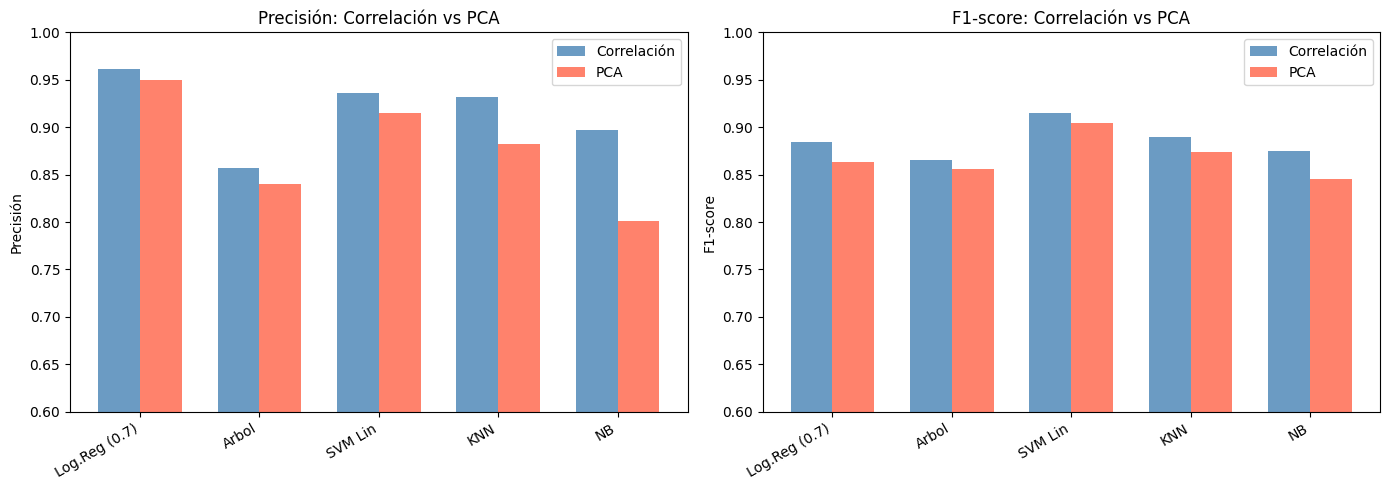

In [64]:
# Resultados del pipeline original (correlación de Pearson)
resultados_correlacion = [
    {'Modelo': 'Regresión Logística (0.7)',   'Accuracy': 0.916, 'Precision': 0.961, 'Recall': 0.819, 'F1-score': 0.884,  'FP': 18, 'FN': 98},
    {'Modelo': 'Red Neuronal (base)',         'Accuracy': 0.930, 'Precision': 0.939, 'Recall': 0.880, 'F1-score': 0.9089,  'FP': 31, 'FN': 65},
    {'Modelo': 'SVM (RBF)',                   'Accuracy': 0.934, 'Precision': 0.936, 'Recall': 0.893, 'F1-score': 0.914, 'FP': 33, 'FN': 58},
    {'Modelo': 'KNN (k=14)',                  'Accuracy': 0.923, 'Precision': 0.961, 'Recall': 0.830, 'F1-score': 0.8915, 'FP': 18, 'FN': 92},
    {'Modelo': 'SVM (linear)',                'Accuracy': 0.934, 'Precision': 0.936, 'Recall': 0.895, 'F1-score': 0.915,  'FP': 33, 'FN': 57},
    {'Modelo': 'Regresión Logística (0.5)',   'Accuracy': 0.924, 'Precision': 0.921, 'Recall': 0.884, 'F1-score': 0.900,  'FP': 41, 'FN': 63},
    {'Modelo': 'KNN (k=5)',                   'Accuracy': 0.918, 'Precision': 0.932, 'Recall': 0.850, 'F1-score': 0.890,  'FP': 34, 'FN': 78},
    {'Modelo': 'Red Neuronal (mejorada)',     'Accuracy': 0.926, 'Precision': 0.912, 'Recall': 0.900, 'F1-score': 0.906,  'FP': 47, 'FN': 54},
    {'Modelo': 'Árbol de decisión',           'Accuracy': 0.892, 'Precision': 0.857, 'Recall': 0.873, 'F1-score': 0.865,  'FP': 79, 'FN': 69},
    {'Modelo': 'Árbol de decisión (mejorado)','Accuracy': 0.884, 'Precision': 0.876, 'Recall': 0.823, 'F1-score': 0.849,  'FP': 63, 'FN': 96},
    {'Modelo': 'Naive Bayes',                 'Accuracy': 0.904, 'Precision': 0.897, 'Recall': 0.854, 'F1-score': 0.875,  'FP': 53, 'FN': 79},
]

df_corr = pd.DataFrame(resultados_correlacion)
df_corr['Pipeline'] = 'Correlación'
df_pca_res = df_resultados_pca[['Modelo','Accuracy','Precisión','Recall','F1-score','FP','FN']].copy()
df_pca_res['Pipeline'] = 'PCA'

# Visualización comparativa de Precision y Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precisión
modelos_base = ['Log.Reg (0.7)', 'Arbol', 'SVM Lin', 'KNN', 'NB']
prec_corr = [0.961, 0.857, 0.936, 0.932, 0.897]
prec_pca  = [
    precision_score(y_test_pca, y_pred_log_pca_07),
    precision_score(y_test_pca, y_pred_tree_pca),
    precision_score(y_test_pca, y_pred_svm_pca),
    precision_score(y_test_pca, y_pred_knn_pca),
    precision_score(y_test_pca, y_pred_nb_pca),
]

x = np.arange(len(modelos_base))
width = 0.35

axes[0].bar(x - width/2, prec_corr, width, label='Correlación', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, prec_pca,  width, label='PCA',         color='tomato',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_base, rotation=30, ha='right')
axes[0].set_ylabel('Precisión')
axes[0].set_title('Precisión: Correlación vs PCA')
axes[0].legend()
axes[0].set_ylim(0.6, 1.0)

# F1-score
f1_corr = [0.884, 0.865, 0.915, 0.89, 0.875]
f1_pca  = [
    f1_score(y_test_pca, y_pred_log_pca_07),
    f1_score(y_test_pca, y_pred_tree_pca),
    f1_score(y_test_pca, y_pred_svm_pca),
    f1_score(y_test_pca, y_pred_knn_pca),
    f1_score(y_test_pca, y_pred_nb_pca),
]

axes[1].bar(x - width/2, f1_corr, width, label='Correlación', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, f1_pca,  width, label='PCA',         color='tomato',    alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos_base, rotation=30, ha='right')
axes[1].set_ylabel('F1-score')
axes[1].set_title('F1-score: Correlación vs PCA')
axes[1].legend()
axes[1].set_ylim(0.6, 1.0)

plt.tight_layout()
plt.show()

### Validación cruzada del mejor modelo PCA

In [65]:
from sklearn.model_selection import StratifiedKFold

# Usamos el mismo modelo que resultó mejor en el pipeline original: Reg. Logística (umbral 0.7)
model_cv_pca = LogisticRegression(max_iter=1000)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

precision_scores_pca = []
recall_scores_pca    = []

for train_index, test_index in skf.split(X_pca, y_pca):
    X_train_cv, X_test_cv = X_pca.iloc[train_index], X_pca.iloc[test_index]
    y_train_cv, y_test_cv = y_pca.iloc[train_index], y_pca.iloc[test_index]

    model_cv_pca.fit(X_train_cv, y_train_cv)
    y_prob_cv = model_cv_pca.predict_proba(X_test_cv)[:, 1]
    y_pred_cv = (y_prob_cv >= 0.7).astype(int)

    precision_scores_pca.append(precision_score(y_test_cv, y_pred_cv))
    recall_scores_pca.append(recall_score(y_test_cv, y_pred_cv))

print("=== Validación cruzada — Reg. Logística PCA (umbral 0.7) ===")
print("Precision por fold:", [round(p, 3) for p in precision_scores_pca])
print("Precision media:", round(np.mean(precision_scores_pca), 3))
print("\nRecall por fold:", [round(r, 3) for r in recall_scores_pca])
print("Recall medio:", round(np.mean(recall_scores_pca), 3))

=== Validación cruzada — Reg. Logística PCA (umbral 0.7) ===
Precision por fold: [0.928, 0.947, 0.944, 0.935, 0.954]
Precision media: 0.942

Recall por fold: [0.78, 0.793, 0.835, 0.793, 0.743]
Recall medio: 0.789


Vemos que tanto el recall medio como la precisión son inferiores al modelo hecho a partir de la correlación Pearson.

## 10. Conclusión del pipeline PCA

El pipeline alternativo basado en PCA reduce las variables originales a un número menor de componentes que retienen el 95% de la varianza del dataset, eliminando redundancias y correlaciones entre variables.

**Ventajas de PCA frente a la selección por correlación:**
- Aprovecha **toda la información** del dataset (no descarta variables, las combina)
- Elimina la multicolinealidad entre features por construcción
- Las componentes son ortogonales, lo que beneficia especialmente a SVM y regresión logística

**Limitaciones:**
- Las componentes PCA no son interpretables directamente (son combinaciones lineales de las variables originales)
- Puede perder algunas señales discriminativas que la selección por correlación capturaba directamente

La comparación entre ambos pipelines permite identificar qué enfoque de feature engineering ofrece mejor trade-off entre precisión, recall e interpretabilidad para el problema de detección de spam.

## Conclusión final

Los resultados obtenidos muestran que tanto el enfoque basado en correlación lineal como el uso de PCA permiten construir modelos con un rendimiento elevado y bastante consistente, lo que indica que el sistema es estable independientemente del pipeline de preprocesado aplicado. En ambos casos, la mayoría de algoritmos mantienen métricas altas y diferencias relativamente pequeñas, demostrando que los modelos generalizan correctamente y que la información relevante del problema se conserva incluso tras la reducción de dimensionalidad.

Dado que se trata de un problema de detección de spam, se ha puesto especial énfasis en la precisión, ya que minimizar los falsos positivos es fundamental para evitar que correos legítimos sean clasificados como spam. En este aspecto, los mejores resultados se obtuvieron principalmente con las redes neuronales y la regresión logística, alcanzando valores de precisión muy elevados en ambos enfoques. Aunque el pipeline basado en correlación lineal logró métricas ligeramente superiores en la mayoría de casos, PCA mantuvo un rendimiento muy competitivo, confirmando la robustez y estabilidad del sistema.

En conclusión, ambos pipelines resultan válidos para el problema planteado, ofreciendo resultados sólidos y consistentes. Sin embargo, la selección de variables mediante correlación lineal presenta una ligera ventaja al conservar una mayor capacidad predictiva y mejores niveles de precisión, aspecto especialmente importante en un sistema de detección de spam.